# Open Source Libraries in APK Files — Initial Analysis

This notebook loads `dataset.csv` from `./analysis_datasets/`, transforms the `origin` column into two binary indicator columns, and computes the first set of metrics focused on:

- `pkg_name`
- `repo_url`
- `cited`
- `origin_fingerprint`
- `origin_license_exposure`
- `fingerprint_types`

The dataset appears to contain one row per detected open source library occurrence inside an APK package.

## 1. Setup

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Show more readable tables in notebooks
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)

DATA_PATH = Path('../analysis_datasets/dataset_700.csv')
TAGGED_APPS_FILE = Path('../database/tagged_apps.csv')
OUTPUT_DIR = Path('../analysis_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def save_current_figure(filename, output_dir=OUTPUT_DIR, dpi=300):
    """Save the current matplotlib figure as a PNG file in OUTPUT_DIR."""
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / filename
    plt.gcf().savefig(output_path, dpi=dpi, bbox_inches='tight')
    print(f'Saved graph to: {output_path}')
    return output_path


if not DATA_PATH.exists():
    raise FileNotFoundError(f'Input file not found: {DATA_PATH.resolve()}')

if not TAGGED_APPS_FILE.exists():
    raise FileNotFoundError(f'Tagged apps file not found: {TAGGED_APPS_FILE.resolve()}')

print(f'Using input file: {DATA_PATH.resolve()}')
print(f'Using tagged apps file: {TAGGED_APPS_FILE.resolve()}')


Using input file: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/analysis_datasets/dataset_700.csv
Using tagged apps file: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/database/tagged_apps.csv


## 2. Load the dataset

In [22]:
df = pd.read_csv(DATA_PATH)

print(f'Rows: {len(df):,}')
print(f'Columns: {df.shape[1]:,}')
df.head()

Rows: 108,234
Columns: 13


,pkg_name,repo_host,repo_path,repo_url,cited,origin,libarary_key,library_name,smali_prefix,fingerprint_types,classes_matched,sample_class,sample_class_file
0,ai.asleep.sleepstar,github.com,BoltsFramework/Bolts-Android,https://github.com/BoltsFramework/Bolts-Android,1.0,fingerprints,BoltsFramework/Bolts-Android,Bolts-Android,Lbolts/,java_package,36.0,Lbolts/AggregateException;,data/decoded/ai.asleep.sleepstar/smali_classes3/bolts/AggregateException.smali
1,ai.asleep.sleepstar,github.com,CanHub/Android-Image-Cropper,https://github.com/CanHub/Android-Image-Cropper,1.0,fingerprints,CanHub/Android-Image-Cropper,Android-Image-Cropper,Lcom/canhub/cropper/,kotlin_package,86.0,Lcom/canhub/cropper/BitmapCroppingWorkerJob$Result;,data/decoded/ai.asleep.sleepstar/smali_classes3/com/canhub/cropper/BitmapCroppingWorkerJob$Result.smali
2,ai.asleep.sleepstar,github.com,CanHub/Android-Image-Cropper,https://github.com/CanHub/Android-Image-Cropper,1.0,fingerprints,CanHub/Android-Image-Cropper,Android-Image-Cropper,Lcom/canhub/cropper/utils/,kotlin_package,2.0,Lcom/canhub/cropper/utils/GetFilePathFromUriKt;,data/decoded/ai.asleep.sleepstar/smali_classes3/com/canhub/cropper/utils/GetFilePathFromUriKt.smali
3,ai.asleep.sleepstar,github.com,JetBrains/java-annotations,https://github.com/JetBrains/java-annotations,1.0,fingerprints,JetBrains/java-annotations,java-annotations,Lorg/jetbrains/annotations/,java_package,30.0,Lorg/jetbrains/annotations/ApiStatus$AvailableSince;,data/decoded/ai.asleep.sleepstar/smali_classes9/org/jetbrains/annotations/ApiStatus$AvailableSince.smali
4,ai.asleep.sleepstar,github.com,JetBrains/java-annotations,https://github.com/JetBrains/java-annotations,1.0,fingerprints,JetBrains/java-annotations,java-annotations,Lorg/intellij/lang/annotations/,java_package,27.0,Lorg/intellij/lang/annotations/Flow;,data/decoded/ai.asleep.sleepstar/smali_classes9/org/intellij/lang/annotations/Flow.smali


## 3. Basic data checks

Before calculating metrics, check the main analysis columns and their missing values.

In [23]:
analysis_columns = [
    'pkg_name',
    'repo_url',
    'cited',
    'origin',
    'fingerprint_types'
]

missing_columns = [col for col in analysis_columns if col not in df.columns]
if missing_columns:
    raise KeyError(f'Missing expected columns: {missing_columns}')

df[analysis_columns].info()

<class 'pandas.DataFrame'>
RangeIndex: 108234 entries, 0 to 108233
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   pkg_name           108234 non-null  str    
 1   repo_url           108234 non-null  str    
 2   cited              106680 non-null  float64
 3   origin             108234 non-null  str    
 4   fingerprint_types  108234 non-null  str    
dtypes: float64(1), str(4)
memory usage: 13.5 MB


In [24]:
missing_summary = (
    df[analysis_columns]
    .isna()
    .sum()
    .to_frame('missing_count')
)
missing_summary['missing_ratio'] = missing_summary['missing_count'] / len(df)
missing_summary

,missing_count,missing_ratio
pkg_name,0,0.000000
repo_url,0,0.000000
cited,1554,0.014358
origin,0,0.000000
fingerprint_types,0,0.000000


## 4. Transform `origin` into binary indicator columns

The original `origin` field may contain values such as:

- `fingerprints`
- `license_exposure`
- `fingerprints,license_exposure`

We create two new columns:

- `origin_fingerprint`: `1` when `origin` contains `fingerprints`, otherwise `0`
- `origin_license_exposure`: `1` when `origin` contains `license_exposure`, otherwise `0`

In [25]:
df['origin_clean'] = df['origin'].fillna('').astype(str).str.lower()

df['origin_fingerprint'] = df['origin_clean'].str.contains('fingerprints', regex=False).astype(int)
df['origin_license_exposure'] = df['origin_clean'].str.contains('license_exposure', regex=False).astype(int)

# Keep cited as numeric 0/1 for safer calculations
# Invalid values become NaN, then are filled with 0. Change this if invalid cited values should be treated differently.
df['cited'] = pd.to_numeric(df['cited'], errors='coerce').fillna(0).astype(int)

# Preview the transformation
cols_to_preview = ['origin', 'origin_fingerprint', 'origin_license_exposure', 'cited']
df[cols_to_preview].head(10)

,origin,origin_fingerprint,origin_license_exposure,cited
0,fingerprints,1,0,1
1,fingerprints,1,0,1
2,fingerprints,1,0,1
3,fingerprints,1,0,1
4,fingerprints,1,0,1
5,fingerprints,1,0,1
6,fingerprints,1,0,1
7,fingerprints,1,0,1
8,fingerprints,1,0,1
9,fingerprints,1,0,1


In [26]:
origin_check = (
    df.groupby(['origin', 'origin_fingerprint', 'origin_license_exposure'], dropna=False)
      .size()
      .reset_index(name='rows')
      .sort_values('rows', ascending=False)
)
origin_check

,origin,origin_fingerprint,origin_license_exposure,rows
0,fingerprints,1,0,104756
2,license_exposure,0,1,2360
1,"fingerprints,license_exposure",1,1,1118


In [27]:
# App metadata: pkg_name is the identifier, app_name is the human-readable title.

tagged_apps = pd.read_csv(TAGGED_APPS_FILE)
required_tagged_cols = ['pkg_name', 'app_name', 'downloads', 'category']
missing_tagged_cols = [col for col in required_tagged_cols if col not in tagged_apps.columns]
if missing_tagged_cols:
    raise KeyError(f'Missing expected columns in tagged apps file: {missing_tagged_cols}')

tagged_apps_lookup = (
    tagged_apps[required_tagged_cols]
    .drop_duplicates(subset=['pkg_name'])
    .copy()
)

df = df.merge(
    tagged_apps_lookup,
    on='pkg_name',
    how='left'
)

df['app_name'] = df['app_name'].fillna(df['pkg_name'])
df['category'] = df['category'].fillna('Unknown')


In [28]:
df.head()

,pkg_name,repo_host,repo_path,repo_url,cited,origin,libarary_key,library_name,smali_prefix,fingerprint_types,classes_matched,sample_class,sample_class_file,origin_clean,origin_fingerprint,origin_license_exposure,app_name,downloads,category
0,ai.asleep.sleepstar,github.com,BoltsFramework/Bolts-Android,https://github.com/BoltsFramework/Bolts-Android,1,fingerprints,BoltsFramework/Bolts-Android,Bolts-Android,Lbolts/,java_package,36.0,Lbolts/AggregateException;,data/decoded/ai.asleep.sleepstar/smali_classes3/bolts/AggregateException.smali,fingerprints,1,0,"Sleep AI: Track, Sounds, Alarm",5K+,HEALTH_AND_FITNESS
1,ai.asleep.sleepstar,github.com,CanHub/Android-Image-Cropper,https://github.com/CanHub/Android-Image-Cropper,1,fingerprints,CanHub/Android-Image-Cropper,Android-Image-Cropper,Lcom/canhub/cropper/,kotlin_package,86.0,Lcom/canhub/cropper/BitmapCroppingWorkerJob$Result;,data/decoded/ai.asleep.sleepstar/smali_classes3/com/canhub/cropper/BitmapCroppingWorkerJob$Result.smali,fingerprints,1,0,"Sleep AI: Track, Sounds, Alarm",5K+,HEALTH_AND_FITNESS
2,ai.asleep.sleepstar,github.com,CanHub/Android-Image-Cropper,https://github.com/CanHub/Android-Image-Cropper,1,fingerprints,CanHub/Android-Image-Cropper,Android-Image-Cropper,Lcom/canhub/cropper/utils/,kotlin_package,2.0,Lcom/canhub/cropper/utils/GetFilePathFromUriKt;,data/decoded/ai.asleep.sleepstar/smali_classes3/com/canhub/cropper/utils/GetFilePathFromUriKt.smali,fingerprints,1,0,"Sleep AI: Track, Sounds, Alarm",5K+,HEALTH_AND_FITNESS
3,ai.asleep.sleepstar,github.com,JetBrains/java-annotations,https://github.com/JetBrains/java-annotations,1,fingerprints,JetBrains/java-annotations,java-annotations,Lorg/jetbrains/annotations/,java_package,30.0,Lorg/jetbrains/annotations/ApiStatus$AvailableSince;,data/decoded/ai.asleep.sleepstar/smali_classes9/org/jetbrains/annotations/ApiStatus$AvailableSince.smali,fingerprints,1,0,"Sleep AI: Track, Sounds, Alarm",5K+,HEALTH_AND_FITNESS
4,ai.asleep.sleepstar,github.com,JetBrains/java-annotations,https://github.com/JetBrains/java-annotations,1,fingerprints,JetBrains/java-annotations,java-annotations,Lorg/intellij/lang/annotations/,java_package,27.0,Lorg/intellij/lang/annotations/Flow;,data/decoded/ai.asleep.sleepstar/smali_classes9/org/intellij/lang/annotations/Flow.smali,fingerprints,1,0,"Sleep AI: Track, Sounds, Alarm",5K+,HEALTH_AND_FITNESS


## 5. Metric 1 — Number of rows per `pkg_name`

This represents the total number of open source library occurrences detected for each APK package.

In [29]:
rows_per_pkg = (
    df.groupby(['pkg_name', 'app_name', 'category'], dropna=False)
      .agg(
          library_occurrence_count=('repo_url', 'size'),
          downloads=('downloads', 'first')
      )
      .reset_index()
      .sort_values('library_occurrence_count', ascending=False)
)

rows_per_pkg.head(20)


,pkg_name,app_name,category,library_occurrence_count,downloads
0,ai.asleep.sleepstar,"Sleep AI: Track, Sounds, Alarm",HEALTH_AND_FITNESS,550,5K+
170,com.cuure,Cuure,HEALTH_AND_FITNESS,548,50K+
429,com.piifzmn4yma.pxgujr2i4app,MOMentum Mode,HEALTH_AND_FITNESS,516,10+
439,com.ps86e528cjd.phw7pggapp,The Movement Paradigm®,HEALTH_AND_FITNESS,516,100+
41,care.bewao.nutrition,Wao,HEALTH_AND_FITNESS,510,50K+
161,com.crystalcourses.lifemasters,Life Masters – Gamified Habits,HEALTH_AND_FITNESS,503,10K+
525,com.trainerize.originpersonaltraining,Origin Personal Training,HEALTH_AND_FITNESS,501,5+
528,com.trainerize.regainfitnessapp,ReGain Fitness App,HEALTH_AND_FITNESS,501,1+
529,com.trainerize.resolutefitnessds,Resolute Coaching & Nutrition,HEALTH_AND_FITNESS,501,50+
531,com.trainerize.sweatwithabby,Sweat with Abby,HEALTH_AND_FITNESS,501,5+


In [30]:
pkg_distribution_summary = rows_per_pkg['library_occurrence_count'].describe().to_frame('value')
pkg_distribution_summary

,value
count,699.000000
mean,154.841202
std,135.321475
min,1.000000
25%,42.000000
50%,123.000000
75%,226.500000
max,550.000000


In [31]:
rows_per_pkg.describe()

,library_occurrence_count
count,699.000000
mean,154.841202
std,135.321475
min,1.000000
25%,42.000000
50%,123.000000
75%,226.500000
max,550.000000


Saved graph to: ../analysis_outputs/library_occurrences_per_apk_boxplot.png


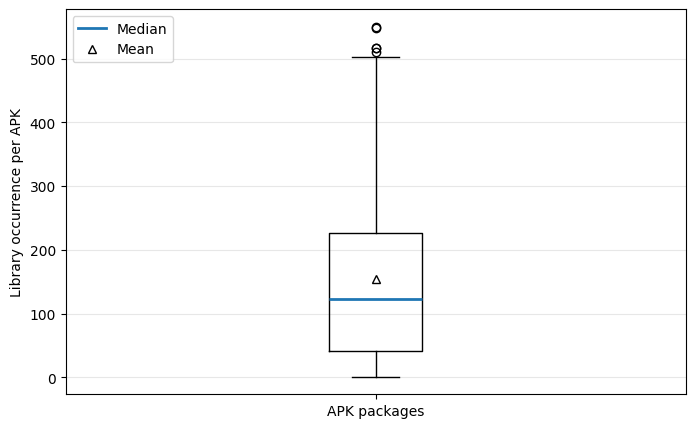

In [43]:
from matplotlib.lines import Line2D

library_counts = rows_per_pkg['library_occurrence_count'].dropna()
median_library_count = library_counts.median()
mean_library_count = library_counts.mean()

plt.figure(figsize=(8, 5))
plt.boxplot(
    library_counts,
    showmeans=True,
    meanprops={'marker': '^', 'markerfacecolor': 'white', 'markeredgecolor': 'black'},
    medianprops={'linewidth': 2, 'color': '#1f77b4'}
)
# plt.title('Distribution of Open Source Library Occurrences per APK')
plt.ylabel('Library occurrence per APK')
plt.xticks([1], ['APK packages'])
plt.grid(True, axis='y', alpha=0.3)

legend_handles = [
    Line2D([0], [0], linewidth=2, label='Median', color='#1f77b4'),
    Line2D([0], [0], marker='^', linestyle='None', markerfacecolor='white', markeredgecolor='black', label='Mean')
]
plt.legend(handles=legend_handles, loc='upper left')

save_current_figure('library_occurrences_per_apk_boxplot.png')
plt.show()


Saved graph to: ../analysis_outputs/library_occurrences_per_apk_histogram.png


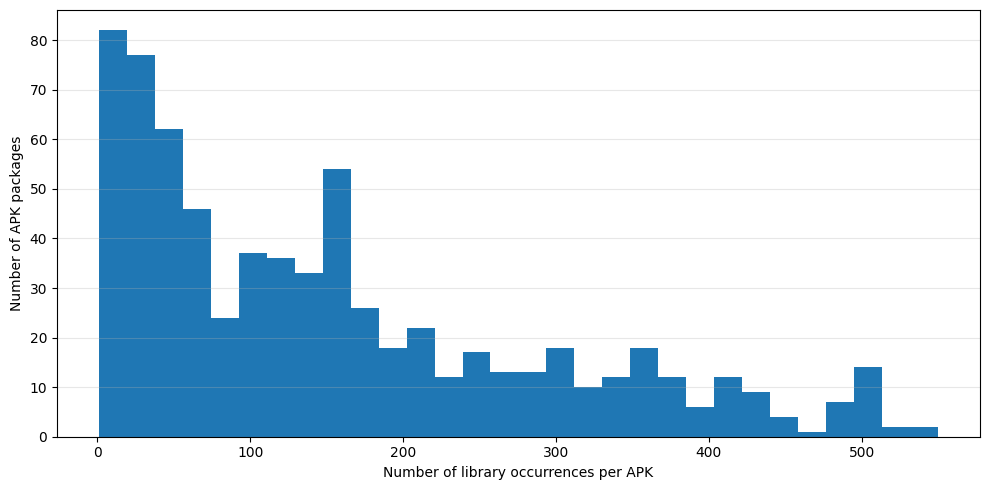

In [33]:
plt.figure(figsize=(10, 5))
plt.hist(rows_per_pkg['library_occurrence_count'].dropna(), bins=30)
# plt.title('Histogram: Open Source Library Occurrences per APK')
plt.xlabel('Number of library occurrences per APK')
plt.ylabel('Number of APK packages')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_current_figure('library_occurrences_per_apk_histogram.png')
plt.show()


## 6. Metric 2 — Total number of rows

This is the total number of open source library occurrences across all APK files.

In [34]:
total_rows = len(df)
print(f'Total open source library occurrences across all APKs: {total_rows:,}')

Total open source library occurrences across all APKs: 108,234


## 7. Metric 3 — Unique count of `repo_url`

Here `repo_url` is used as the open source library identifier.

Note: missing `repo_url` values are excluded from the unique count by default.

In [35]:
unique_repo_url_count = df['repo_url'].dropna().nunique()
missing_repo_url_count = df['repo_url'].isna().sum()

print(f'Unique OS libraries by repo_url: {unique_repo_url_count:,}')
print(f'Rows with missing repo_url: {missing_repo_url_count:,}')

Unique OS libraries by repo_url: 636
Rows with missing repo_url: 0


In [36]:
top_repo_urls = (
    df['repo_url']
    .value_counts(dropna=False)
    .rename_axis('repo_url')
    .reset_index(name='occurrence_count')
)

top_repo_urls.head(20)

,repo_url,occurrence_count
0,https://github.com/material-components/material-components-android,22240
1,https://github.com/facebook/react-native,16152
2,https://github.com/facebook/fresco,13992
3,https://github.com/Kotlin/kotlinx.coroutines,7092
4,https://github.com/androidx/media,6831
5,https://github.com/bumptech/glide,6633
6,https://github.com/zxing/zxing,6077
7,https://github.com/facebook/facebook-android-sdk,4036
8,https://github.com/google/gson,3505
9,https://github.com/airbnb/lottie-android,2057


## 8. Metric 4 — Cited vs. not cited

Count rows where:

- `cited = 1`
- `cited = 0`

Then calculate the ratio of each group relative to total rows.

In [37]:
cited_summary = (
    df['cited']
    .value_counts(dropna=False)
    .rename_axis('cited')
    .reset_index(name='row_count')
    .sort_values('cited', ascending=False)
)

cited_summary['ratio_of_total_rows'] = cited_summary['row_count'] / total_rows
cited_summary

,cited,row_count,ratio_of_total_rows
0,1,59954,0.553929
1,0,48280,0.446071


Saved graph to: ../analysis_outputs/cited_vs_uncited_by_category.png


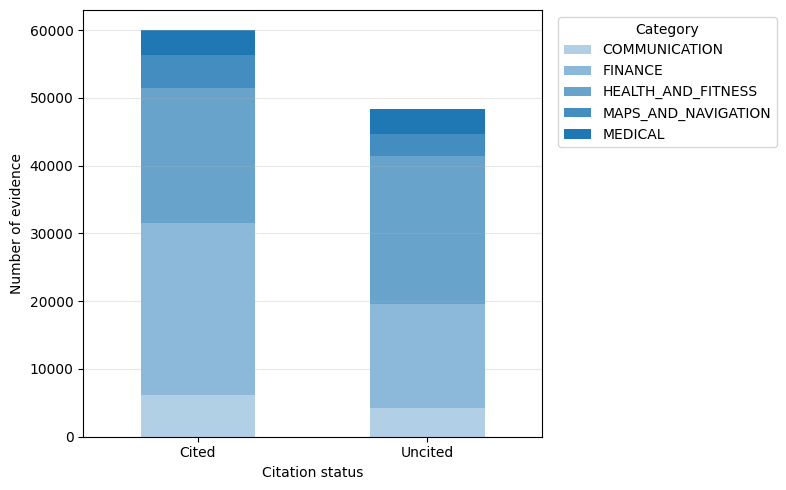

In [38]:
import matplotlib.colors as mcolors
base_blue = '#1f77b4'

cited_category_summary = (
    df.assign(cited_label=np.where(df['cited'] == 1, 'Cited', 'Uncited'))
      .groupby(['cited_label', 'category'], dropna=False)
      .size()
      .reset_index(name='row_count')
)

cited_category_pivot = (
    cited_category_summary
    .pivot(index='cited_label', columns='category', values='row_count')
    .fillna(0)
    .reindex(['Cited', 'Uncited'])
)

blue_shades = [
    mcolors.to_hex(
        np.array(mcolors.to_rgb(base_blue)) * factor + np.array([1, 1, 1]) * (1 - factor)
    )
    for factor in np.linspace(0.35, 1.0, len(cited_category_pivot.columns))
]

ax = cited_category_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=blue_shades
)
# ax.set_title('Cited vs. Uncited Library Occurrences by App Category')
ax.set_xlabel('Citation status')
ax.set_ylabel('Number of evidence')
ax.grid(axis='y', alpha=0.3) 
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
save_current_figure('cited_vs_uncited_by_category.png')
plt.show()


## 9. Metric 5 — Cited rows found by fingerprints

Among rows where `cited = 1`, count how many also have `origin_fingerprint = 1`.

The ratio is calculated as:

`cited rows found by fingerprints / total cited rows`

In [39]:
cited_df = df[df['cited'] == 1].copy()
total_cited = len(cited_df)

cited_found_by_fingerprint = int((cited_df['origin_fingerprint'] == 1).sum())
fingerprint_ratio_among_cited = cited_found_by_fingerprint / total_cited if total_cited else np.nan

print(f'Total cited rows: {total_cited:,}')
print(f'Cited rows found by fingerprints: {cited_found_by_fingerprint:,}')
print(f'Ratio among cited rows: {fingerprint_ratio_among_cited:.2%}' if total_cited else 'Ratio among cited rows: undefined because there are no cited rows')

Total cited rows: 59,954
Cited rows found by fingerprints: 57,594
Ratio among cited rows: 96.06%


## 10. Metric 6 — Cited rows found by license exposure

Among rows where `cited = 1`, count how many also have `origin_license_exposure = 1`.

The ratio is calculated as:

`cited rows found by license exposure / total cited rows`

In [40]:
cited_found_by_license_exposure = int((cited_df['origin_license_exposure'] == 1).sum())
license_exposure_ratio_among_cited = cited_found_by_license_exposure / total_cited if total_cited else np.nan

print(f'Total cited rows: {total_cited:,}')
print(f'Cited rows found by license exposure: {cited_found_by_license_exposure:,}')
print(f'Ratio among cited rows: {license_exposure_ratio_among_cited:.2%}' if total_cited else 'Ratio among cited rows: undefined because there are no cited rows')

Total cited rows: 59,954
Cited rows found by license exposure: 3,478
Ratio among cited rows: 5.80%


In [41]:
cited_origin_summary = pd.DataFrame({
    'origin_indicator': ['origin_fingerprint', 'origin_license_exposure'],
    'cited_row_count': [cited_found_by_fingerprint, cited_found_by_license_exposure],
})

cited_origin_summary['ratio_among_cited_rows'] = cited_origin_summary['cited_row_count'] / total_cited if total_cited else np.nan
cited_origin_summary

,origin_indicator,cited_row_count,ratio_among_cited_rows
0,origin_fingerprint,57594,0.960636
1,origin_license_exposure,3478,0.058011


Saved graph to: ../analysis_outputs/cited_rows_by_detection_origin_category.png


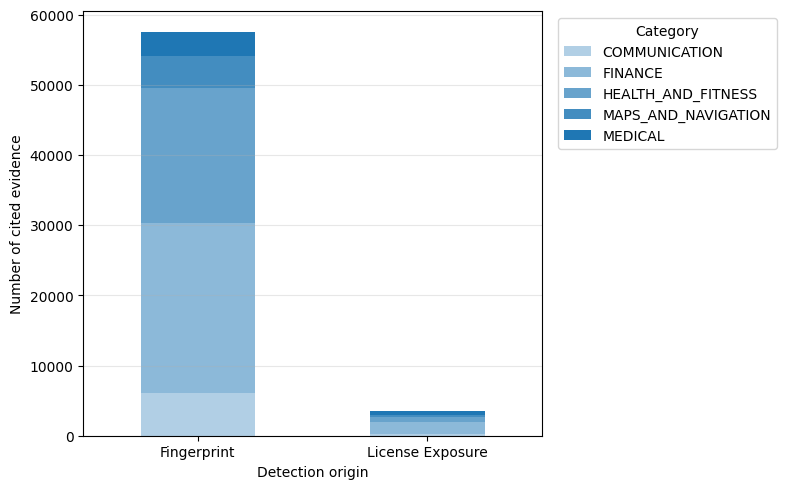

In [42]:
origin_category_rows = []
for indicator, label in [
    ('origin_fingerprint', 'Fingerprint'),
    ('origin_license_exposure', 'License Exposure')
]:
    temp = (
        cited_df[cited_df[indicator] == 1]
        .groupby('category', dropna=False)
        .size()
        .reset_index(name='cited_row_count')
    )
    temp['origin_label'] = label
    origin_category_rows.append(temp)

origin_category_summary = pd.concat(origin_category_rows, ignore_index=True)
origin_category_pivot = (
    origin_category_summary
    .pivot(index='origin_label', columns='category', values='cited_row_count')
    .fillna(0)
    .reindex(['Fingerprint', 'License Exposure'])
)

blue_shades = [
    mcolors.to_hex(
        np.array(mcolors.to_rgb(base_blue)) * factor + np.array([1, 1, 1]) * (1 - factor)
    )
    for factor in np.linspace(0.35, 1.0, len(origin_category_pivot.columns))
]
ax = origin_category_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=blue_shades
)
# ax.set_title('Cited Rows by Detection Origin and App Category')
ax.set_xlabel('Detection origin')
ax.set_ylabel('Number of cited evidence')
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
save_current_figure('cited_rows_by_detection_origin_category.png')
plt.show()


## 11. Metric 7 — Ratio of `fingerprint_types`

This calculates the count and percentage share of each `fingerprint_types` value.

Rows with missing `fingerprint_types` are included as `missing` so the percentages sum to 100%.

In [54]:
fingerprint_type_summary = (
    df['fingerprint_types']
    .fillna('missing')
    .value_counts(dropna=False)
    .rename_axis('fingerprint_types')
    .reset_index(name='row_count')
)

fingerprint_type_summary['ratio_of_total_rows'] = fingerprint_type_summary['row_count'] / total_rows
fingerprint_type_summary

,fingerprint_types,row_count,ratio_of_total_rows
0,java_package,66795,0.617135
1,kotlin_package,34590,0.319585
2,manifest_package,2927,0.027043
3,js_license_header,1767,0.016326
4,maven_artifact_root,694,0.006412
5,gradle_group_prefix,407,0.003760
6,javascript_define,335,0.003095
7,generic_text_repo_url,332,0.003067
8,json_license_heuristic,257,0.002374
9,maven_group_prefix,126,0.001164


Saved graph to: ../analysis_outputs/fingerprint_type_ratio.png


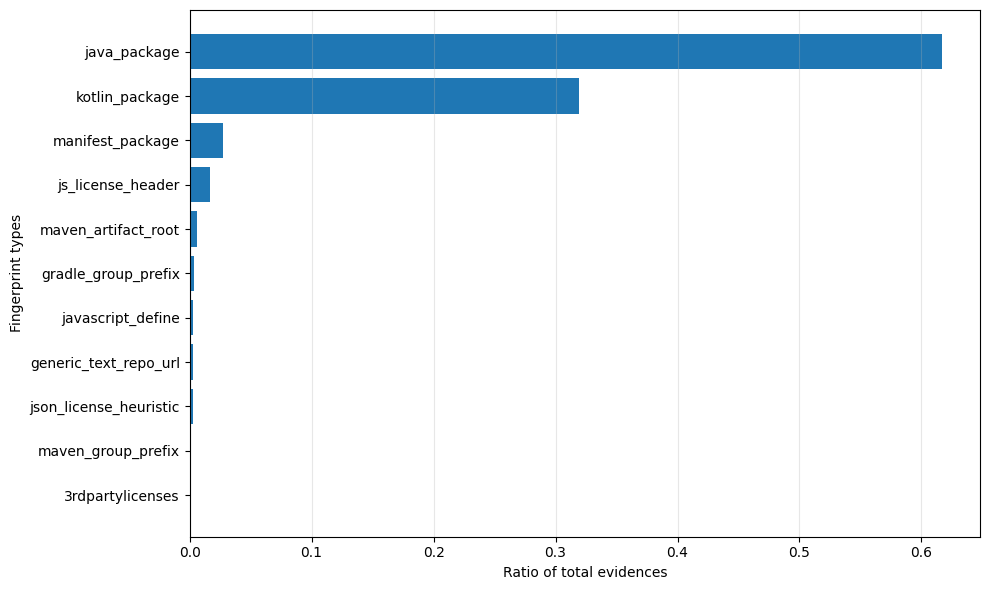

In [55]:
plt.figure(figsize=(10, 6))
plt.barh(fingerprint_type_summary['fingerprint_types'].astype(str), fingerprint_type_summary['ratio_of_total_rows'])
# plt.title('Fingerprint Type Ratio')
plt.xlabel('Ratio of total evidences')
plt.ylabel('Fingerprint types')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
save_current_figure('fingerprint_type_ratio.png')
plt.show()


## 12. Combined KPI summary

In [56]:
kpi_summary = pd.DataFrame({
    'metric': [
        'Total rows / library occurrences',
        'Unique APK packages',
        'Unique OS libraries by repo_url',
        'Rows with missing repo_url',
        'Cited rows',
        'Not cited rows',
        'Cited ratio of total rows',
        'Not cited ratio of total rows',
        'Cited rows found by fingerprints',
        'Fingerprint ratio among cited rows',
        'Cited rows found by license exposure',
        'License exposure ratio among cited rows',
        'Average library occurrences per APK',
        'Minimum library occurrences per APK',
        'Maximum library occurrences per APK'
    ],
    'value': [
        total_rows,
        df['pkg_name'].nunique(dropna=True),
        unique_repo_url_count,
        missing_repo_url_count,
        int((df['cited'] == 1).sum()),
        int((df['cited'] == 0).sum()),
        (df['cited'] == 1).sum() / total_rows if total_rows else np.nan,
        (df['cited'] == 0).sum() / total_rows if total_rows else np.nan,
        cited_found_by_fingerprint,
        fingerprint_ratio_among_cited,
        cited_found_by_license_exposure,
        license_exposure_ratio_among_cited,
        rows_per_pkg['library_occurrence_count'].mean(),
        rows_per_pkg['library_occurrence_count'].min(),
        rows_per_pkg['library_occurrence_count'].max()
    ]
})

kpi_summary

,metric,value
0,Total rows / library occurrences,108234.000000
1,Unique APK packages,699.000000
2,Unique OS libraries by repo_url,636.000000
3,Rows with missing repo_url,0.000000
4,Cited rows,59954.000000
5,Not cited rows,48280.000000
6,Cited ratio of total rows,0.553929
7,Not cited ratio of total rows,0.446071
8,Cited rows found by fingerprints,57594.000000
9,Fingerprint ratio among cited rows,0.960636


## 13. Optional: save transformed dataset and summary tables

This section saves the transformed dataset and metric tables into `./analysis_outputs/` for later use.

In [57]:
transformed_path = OUTPUT_DIR / 'dataset_transformed.csv'
kpi_path = OUTPUT_DIR / 'kpi_summary.csv'
rows_per_pkg_path = OUTPUT_DIR / 'rows_per_pkg.csv'
fingerprint_type_summary_path = OUTPUT_DIR / 'fingerprint_type_summary.csv'

# Save outputs
df.to_csv(transformed_path, index=False)
kpi_summary.to_csv(kpi_path, index=False)
rows_per_pkg.to_csv(rows_per_pkg_path, index=False)
fingerprint_type_summary.to_csv(fingerprint_type_summary_path, index=False)

print(f'Saved transformed dataset to: {transformed_path}')
print(f'Saved KPI summary to: {kpi_path}')
print(f'Saved rows-per-package summary to: {rows_per_pkg_path}')
print(f'Saved fingerprint type summary to: {fingerprint_type_summary_path}')


Saved transformed dataset to: ../analysis_outputs/dataset_transformed.csv
Saved KPI summary to: ../analysis_outputs/kpi_summary.csv
Saved rows-per-package summary to: ../analysis_outputs/rows_per_pkg.csv
Saved fingerprint type summary to: ../analysis_outputs/fingerprint_type_summary.csv


## 14. Notes for next analysis steps

Possible next steps:

1. Analyze citation behavior by APK package.
2. Compare cited vs. uncited libraries by `repo_url`.
3. Identify libraries that appear frequently but are rarely cited.
4. Analyze overlap between fingerprint-based detection and license-exposure detection.
5. Expand `fingerprint_types` analysis by APK package and by citation status.